# Semantic coding of neurons in TP

We previously launched the script Semantic_Coding_Processing.py to obtain the correlation between semantic and neuronal space.

We now want to see if semantic coding is higher for concept cells than for responsive cells.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [2]:
# Open csv file containing results

path_csv = 'C:/Users/dornier/GitHub/ConceptCells_DecMem/data/Semantic_Coding/'

df = pd.read_csv(path_csv+'Semantic_Coding_TP.csv')



# Analyses on concept cells only

In the following part we will compute the same analysis but only on cells identified as concept cells

Concept cells are selected according to the following criteria :
1) Selectivity to some concepts
2) Invariant response
3) Response to all trials

In [ ]:
# List of concept cells

dict_concept = {
    'sub-97': {
        'sess-1': [6,7,9,15,16,19],
        'sess-2': [3,4,5],
        'sess-3': [3]
    },
    'sub-117': {
        'sess-2': [2]
    },
    'sub-118': {
        'sess-3': [126,157,162,168,184]
    },
    'sub-127': {
        'sess-4': [26]
    },
    'sub-131': {
        'sess-2': [35,39],
        'sess-3': [32],
        'sess-4': [29,36,37],
        'sess-5': [25]
    }
}

In [4]:
# Extract informations of interest from the dictionnary above

# Initialize list for storing correlation of neurons responsive
corr_concepts = []


# Get the list of the patient with responsive units
list_patient = list(dict_concept.keys())

# Loop over this list of patient with responsive units
for iPatient in list_patient:

    # Extract from the original dataframe 
    df2 = df[df['ID Patient'] == iPatient]


    # Extract sessions from the dictionnary
    list_session = list(dict_concept[iPatient].keys())

    # Loop oversessions
    for iSession in list_session:
        
        # Extract from the dataframe
        df3 = df2[df2['ID Session']==iSession]

        
        # Get the list of unit responsive 
        list_neuron = dict_concept[iPatient][iSession]
        
        for iNeuron in list_neuron:
            df4 = df3[df3['ID Neurone'] == iNeuron]

            
            corr_concepts.append(df4['Z-score'])

    
corr_concepts = np.squeeze(np.array(corr_concepts))

# Statistical testing

In [5]:
# Test for differences between all dataset and responsive units

corr_all = df['Z-score'].values

corr_all = corr_all[~np.isnan(corr_all)]

corr_concepts = corr_concepts[~np.isnan(corr_concepts)]

resultats = stats.mannwhitneyu(corr_all,corr_concepts[~np.isnan(corr_concepts)])

print('p-value = ' + str(resultats.pvalue))

p-value = 0.04309437162644523


In [6]:
# Descriptive statistics

mean_corr_all = np.mean(corr_all)
std_corr_all = np.std(corr_all)

mean_corr_concepts = np.mean(corr_concepts)
std_corr_concepts = np.std(corr_concepts)

print('Moyenne all = '+str(mean_corr_all)+', SD = '+str(std_corr_all))

print('\nMoyenne concept cells = '+str(mean_corr_concepts)+', SD = '+str(std_corr_concepts))

Moyenne all = 0.4242339378203713, SD = 1.332482259470351

Moyenne concept cells = 1.0794830571325795, SD = 1.513805833137991


# Plot

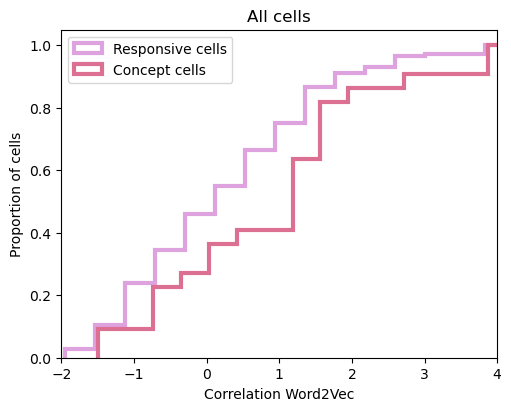

In [7]:
fig, (ax1) = plt.subplots(1,1,figsize=(5,4),layout='constrained',sharex=True)

ax1.hist(df['Z-score'],bins=15,color='plum',alpha=0.97,density=True,histtype='step',linewidth=3,cumulative=True)

ax1.set_ylabel('Proportion of cells')

ax1.hist(corr_concepts,bins=15, color='palevioletred',density=True,histtype='step',linewidth=3,cumulative=True)
ax1.set_xlabel('Correlation Word2Vec')
ax1.set_title('All cells')
ax1.set_xlim(-2,4)
ax1.legend(['Responsive cells','Concept cells'])
plt.savefig(path_csv+'/Semantic_Coding_ConceptCells_VS_Responsive.svg')